In [1]:
# ── Libraries ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [6]:
# ── Load dataset ────────────────────────────────────────
df = pd.read_csv('/Users/apple/Documents/GitHub/airline-revenue-management/flights_clean.csv')

print(f"✅ Dataset loaded successfully")
print(f"📊 Shape : {df.shape[0]} rows × {df.shape[1]} columns")

✅ Dataset loaded successfully
📊 Shape : 10683 rows × 12 columns


In [7]:
df.head(10)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Revenue
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,22/03/26 1:10,2h 50m,non-stop,No info,3897,3897
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,5:50,13:15,7h 25m,2 stops,No info,7662,7662
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,9:25,10/06/26 4:25,19h,2 stops,No info,13882,13882
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,6218
4,IndiGo,2019-03-24,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,13302
5,SpiceJet,2019-05-01,Kolkata,Banglore,CCU → BLR,9:00,11:25,2h 25m,non-stop,No info,3873,3873
6,Jet Airways,2019-06-09,Banglore,New Delhi,BLR → BOM → DEL,18:55,13/03/26 10:25,15h 30m,1 stop,In-flight meal not included,11087,11087
7,Jet Airways,2019-05-12,Banglore,New Delhi,BLR → BOM → DEL,8:00,02/03/26 5:05,21h 5m,1 stop,No info,22270,22270
8,Jet Airways,2019-03-24,Banglore,New Delhi,BLR → BOM → DEL,8:55,13/03/26 10:25,25h 30m,1 stop,In-flight meal not included,11087,11087
9,Multiple carriers,2019-05-01,Delhi,Cochin,DEL → BOM → COK,11:25,19:15,7h 50m,1 stop,No info,8625,8625


In [8]:
# ── Preview data ────────────────────────────────────────
print("=" * 55)
print("FIRST 10 ROWS")
print("=" * 55)
df.head(10)

FIRST 10 ROWS


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Revenue
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,22/03/26 1:10,2h 50m,non-stop,No info,3897,3897
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,5:50,13:15,7h 25m,2 stops,No info,7662,7662
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,9:25,10/06/26 4:25,19h,2 stops,No info,13882,13882
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,6218
4,IndiGo,2019-03-24,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,13302
5,SpiceJet,2019-05-01,Kolkata,Banglore,CCU → BLR,9:00,11:25,2h 25m,non-stop,No info,3873,3873
6,Jet Airways,2019-06-09,Banglore,New Delhi,BLR → BOM → DEL,18:55,13/03/26 10:25,15h 30m,1 stop,In-flight meal not included,11087,11087
7,Jet Airways,2019-05-12,Banglore,New Delhi,BLR → BOM → DEL,8:00,02/03/26 5:05,21h 5m,1 stop,No info,22270,22270
8,Jet Airways,2019-03-24,Banglore,New Delhi,BLR → BOM → DEL,8:55,13/03/26 10:25,25h 30m,1 stop,In-flight meal not included,11087,11087
9,Multiple carriers,2019-05-01,Delhi,Cochin,DEL → BOM → COK,11:25,19:15,7h 50m,1 stop,No info,8625,8625


In [9]:
# ── Column info ─────────────────────────────────────────
print("=" * 55)
print("COLUMN NAMES AND DATA TYPES")
print("=" * 55)
print(df.dtypes)
print()
print(f"Total columns : {df.shape[1]}")

COLUMN NAMES AND DATA TYPES
Airline              str
Date_of_Journey      str
Source               str
Destination          str
Route                str
Dep_Time             str
Arrival_Time         str
Duration             str
Total_Stops          str
Additional_Info      str
Price              int64
Revenue            int64
dtype: object

Total columns : 12


In [10]:
# ── Fix Date_of_Journey ─────────────────────────────────
df['Date_of_Journey'] = pd.to_datetime(
    df['Date_of_Journey'], dayfirst=True)

# Extract useful features from date
df['journey_month']    = df['Date_of_Journey'].dt.month
df['journey_day']      = df['Date_of_Journey'].dt.day
df['journey_weekday']  = df['Date_of_Journey'].dt.dayofweek
df['journey_quarter']  = df['Date_of_Journey'].dt.quarter
df['month_name']       = df['Date_of_Journey'].dt.strftime('%b')

print("✅ Date_of_Journey fixed")
print(df[['Date_of_Journey','journey_month',
          'journey_day','month_name']].head(5))

✅ Date_of_Journey fixed
  Date_of_Journey  journey_month  journey_day month_name
0      2019-03-24              3           24        Mar
1      2019-05-01              5            1        May
2      2019-06-09              6            9        Jun
3      2019-05-12              5           12        May
4      2019-03-24              3           24        Mar


In [16]:
# ── Fix Dep_Time — same mixed format handler ────────────
def parse_dep_time(val):
    val = str(val).strip()
    
    # Try format 1: DD/MM/YY H:MM
    try:
        return pd.to_datetime(val, format='%d/%m/%y %H:%M')
    except:
        pass
    
    # Try format 2: HH:MM
    try:
        return pd.to_datetime(val, format='%H:%M')
    except:
        pass
    
    # Try format 3: H:MM AM/PM
    try:
        return pd.to_datetime(val, format='%I:%M %p')
    except:
        pass

    # Try format 4: DD/MM/YYYY H:MM
    try:
        return pd.to_datetime(val, format='%d/%m/%Y %H:%M')
    except:
        pass

    return pd.NaT

df['dep_datetime']    = df['Dep_Time'].apply(parse_dep_time)
df['dep_hour']        = df['dep_datetime'].dt.hour
df['dep_time_of_day'] = df['dep_hour'].apply(time_of_day)

total     = len(df)
parsed_ok = df['dep_hour'].notna().sum()
failed    = df['dep_hour'].isna().sum()

print("=" * 55)
print("DEP TIME PARSING RESULTS")
print("=" * 55)
print(f"Total rows          : {total:,}")
print(f"Parsed successfully : {parsed_ok:,}")
print(f"Failed (NaN)        : {failed:,}")
print(f"Success rate        : {parsed_ok/total*100:.1f}%")
print()
print(df[['Dep_Time','dep_hour','dep_time_of_day']].head(15))

if failed > 0:
    print(f"\n⚠️  Still failing — sample values:")
    print(df[df['dep_hour'].isna()]['Dep_Time']\
          .head(10).tolist())

DEP TIME PARSING RESULTS
Total rows          : 10,683
Parsed successfully : 10,683
Failed (NaN)        : 0
Success rate        : 100.0%

   Dep_Time  dep_hour dep_time_of_day
0     22:20        22           Night
1      5:50         5         Morning
2      9:25         9         Morning
3     18:05        18         Evening
4     16:50        16       Afternoon
5      9:00         9         Morning
6     18:55        18         Evening
7      8:00         8         Morning
8      8:55         8         Morning
9     11:25        11         Morning
10     9:45         9         Morning
11    20:20        20         Evening
12    11:40        11         Morning
13    21:10        21           Night
14    17:15        17         Evening


In [15]:
# ── Fix Arrival_Time — mixed format handler ─────────────
def parse_arrival_time(val):
    val = str(val).strip()
    
    # Try format 1: DD/MM/YY H:MM  e.g. "22/03/26 1:10"
    try:
        return pd.to_datetime(val, format='%d/%m/%y %H:%M')
    except:
        pass
    
    # Try format 2: HH:MM  e.g. "22:20" or "1:10"
    try:
        return pd.to_datetime(val, format='%H:%M')
    except:
        pass
    
    # Try format 3: H:MM AM/PM  e.g. "6:05 AM"
    try:
        return pd.to_datetime(val, format='%I:%M %p')
    except:
        pass

    # Try format 4: DD/MM/YYYY H:MM  e.g. "22/03/2026 1:10"
    try:
        return pd.to_datetime(val, format='%d/%m/%Y %H:%M')
    except:
        pass

    # If all fail return NaT
    return pd.NaT

# Apply to full column
df['arrival_datetime'] = df['Arrival_Time'].apply(parse_arrival_time)

# Extract hour
df['arrival_hour'] = df['arrival_datetime'].dt.hour

# Time of day category
def time_of_day(hour):
    if pd.isna(hour):
        return 'Unknown'
    elif 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['arrival_time_of_day'] = df['arrival_hour'].apply(time_of_day)

# Flag next day arrivals only where full date is available
df['next_day_arrival'] = (
    df['arrival_datetime'].dt.date > df['Date_of_Journey'].dt.date
).astype(int)

# Verification
total      = len(df)
parsed_ok  = df['arrival_hour'].notna().sum()
failed     = df['arrival_hour'].isna().sum()

print("=" * 55)
print("ARRIVAL TIME PARSING RESULTS")
print("=" * 55)
print(f"Total rows          : {total:,}")
print(f"Parsed successfully : {parsed_ok:,}")
print(f"Failed (NaN)        : {failed:,}")
print(f"Success rate        : {parsed_ok/total*100:.1f}%")
print()
print(df[['Arrival_Time','arrival_hour',
          'arrival_time_of_day',
          'next_day_arrival']].head(15))

# Show remaining failed values if any
if failed > 0:
    print(f"\n⚠️  Still failing — sample values:")
    print(df[df['arrival_hour'].isna()]['Arrival_Time']\
          .head(10).tolist())

ARRIVAL TIME PARSING RESULTS
Total rows          : 10,683
Parsed successfully : 10,683
Failed (NaN)        : 0
Success rate        : 100.0%

      Arrival_Time  arrival_hour arrival_time_of_day  next_day_arrival
0    22/03/26 1:10             1               Night                 1
1            13:15            13           Afternoon                 0
2    10/06/26 4:25             4               Night                 1
3            23:30            23               Night                 0
4            21:35            21               Night                 0
5            11:25            11             Morning                 0
6   13/03/26 10:25            10             Morning                 1
7    02/03/26 5:05             5             Morning                 1
8   13/03/26 10:25            10             Morning                 1
9            19:15            19             Evening                 0
10           23:00            23               Night                 0
11     

In [17]:
# ── Fix Duration ────────────────────────────────────────
def parse_duration(dur):
    dur = str(dur).strip()
    hours   = 0
    minutes = 0
    if 'h' in dur:
        hours = int(dur.split('h')[0].strip())
    if 'm' in dur:
        minutes = int(dur.split('m')[0].split()[-1].strip())
    return (hours * 60) + minutes

df['duration_mins'] = df['Duration'].apply(parse_duration)

# Sanity check — flag anything under 30 mins or over 600 mins
invalid_duration = df[
    (df['duration_mins'] < 30) |
    (df['duration_mins'] > 600)
]
print(f"⚠️  Suspicious duration rows : {len(invalid_duration)}")
print("✅ Duration fixed")
print(df[['Duration','duration_mins']].head(10))

⚠️  Suspicious duration rows : 4711
✅ Duration fixed
  Duration  duration_mins
0   2h 50m            170
1   7h 25m            445
2      19h           1140
3   5h 25m            325
4   4h 45m            285
5   2h 25m            145
6  15h 30m            930
7   21h 5m           1265
8  25h 30m           1530
9   7h 50m            470


In [24]:
# ── Fix Total_Stops — handle 1 NaN row ──────────────────
stops_map = {
    'non-stop' : 0,
    '1 stop'   : 1,
    '2 stops'  : 2,
    '3 stops'  : 3,
    '4 stops'  : 4
}

df['stops_clean'] = df['Total_Stops']\
    .str.strip()\
    .str.lower()\
    .map(stops_map)

# Fill the 1 missing row with median (most common sense approach)
median_stops = df['stops_clean'].median()
df['stops_clean'] = df['stops_clean'].fillna(median_stops)

# Convert to integer now that no NaN exists
df['stops_clean'] = df['stops_clean'].astype(int)

# Verify
print("=" * 55)
print("TOTAL STOPS — CLEAN")
print("=" * 55)
print(df['stops_clean'].value_counts().sort_index())
print()
print(f"Data type     : {df['stops_clean'].dtype}")
print(f"Missing values: {df['stops_clean'].isna().sum()}")
print()
print(df[['Total_Stops','stops_clean']].head(10))
print("✅ Total_Stops fully cleaned")

TOTAL STOPS — CLEAN
stops_clean
0    3491
1    5626
2    1520
3      45
4       1
Name: count, dtype: int64

Data type     : int64
Missing values: 0

  Total_Stops  stops_clean
0    non-stop            0
1     2 stops            2
2     2 stops            2
3      1 stop            1
4      1 stop            1
5    non-stop            0
6      1 stop            1
7      1 stop            1
8      1 stop            1
9      1 stop            1
✅ Total_Stops fully cleaned


In [25]:
# ── Full cleaning status check ───────────────────────────
print("=" * 55)
print("CLEANING STATUS — ALL COLUMNS")
print("=" * 55)

cols = {
    'Date_of_Journey' : 'datetime64[ns]',
    'dep_hour'        : 'int or float',
    'arrival_hour'    : 'int or float',
    'duration_mins'   : 'int or float',
    'stops_clean'     : 'int64',
    'Price'           : 'int64',
    'Revenue'         : 'int64'
}

for col, expected in cols.items():
    if col in df.columns:
        null_count = df[col].isna().sum()
        status = "✅" if null_count == 0 else f"⚠️  {null_count} nulls"
        print(f"{col:<22} | {str(df[col].dtype):<18} | {status}")

CLEANING STATUS — ALL COLUMNS
Date_of_Journey        | datetime64[us]     | ✅
dep_hour               | int32              | ✅
arrival_hour           | int32              | ✅
duration_mins          | int64              | ✅
stops_clean            | int64              | ✅
Price                  | int64              | ✅
Revenue                | int64              | ✅


In [26]:
# ── Final check ─────────────────────────────────────────
print("=" * 55)
print("COLUMN TYPES AFTER CLEANING")
print("=" * 55)

cols_to_check = [
    'Date_of_Journey', 'journey_month', 'journey_weekday',
    'dep_hour', 'dep_time_of_day',
    'arrival_hour', 'next_day_arrival',
    'duration_mins', 'stops_clean',
    'Price', 'Revenue'
]

for col in cols_to_check:
    if col in df.columns:
        print(f"{col:<22} : {str(df[col].dtype):<10} "
              f"| sample: {df[col].iloc[0]}")

COLUMN TYPES AFTER CLEANING
Date_of_Journey        : datetime64[us] | sample: 2019-03-24 00:00:00
journey_month          : int32      | sample: 3
journey_weekday        : int32      | sample: 6
dep_hour               : int32      | sample: 22
dep_time_of_day        : str        | sample: Night
arrival_hour           : int32      | sample: 1
next_day_arrival       : int64      | sample: 1
duration_mins          : int64      | sample: 170
stops_clean            : int64      | sample: 0
Price                  : int64      | sample: 3897
Revenue                : int64      | sample: 3897


In [29]:
# ── Export clean dataset ────────────────────────────────
df.to_csv('/data/flights_processed.csv', index=False)

print("=" * 55)
print("CLEANING COMPLETE — SUMMARY")
print("=" * 55)
print(f"Total rows saved     : {len(df):,}")
print(f"Total columns        : {df.shape[1]}")
print(f"Duration range       : {df['duration_mins'].min()}"
      f"–{df['duration_mins'].max()} mins")
print(f"Stop values          : {sorted(df['stops_clean'].dropna().unique().tolist())}")
print(f"Month range          : {df['journey_month'].min()}"
      f"–{df['journey_month'].max()}")
print(f"Dep hour range       : {df['dep_hour'].min()}"
      f"–{df['dep_hour'].max()}")
print()
print("✅ flights_processed.csv saved to data/ folder")

OSError: Cannot save file into a non-existent directory: '/data'

In [34]:
import os

# ── Hard set correct project root ───────────────────────
PROJECT_ROOT = '/Users/apple/Documents/GitHub/airline-revenue-management'

# Your folders (match exact capitalisation from your machine)
DATA_DIR     = os.path.join(PROJECT_ROOT, 'Data')
SCREENSHOTS  = os.path.join(PROJECT_ROOT, 'Screenshots', 'python')
SQL_DIR      = os.path.join(PROJECT_ROOT, 'SQL')
PYTHON_DIR   = os.path.join(PROJECT_ROOT, 'Python')

# Create screenshots/python subfolder if missing
os.makedirs(SCREENSHOTS, exist_ok=True)

print("=" * 55)
print("PATH CONFIGURATION")
print("=" * 55)
print(f"Project root  : {PROJECT_ROOT}")
print(f"Data folder   : {DATA_DIR}")
print(f"Screenshots   : {SCREENSHOTS}")
print()

# ── Check what is in Data/ folder ───────────────────────
print("Contents of Data/ folder:")
if os.path.exists(DATA_DIR):
    for f in os.listdir(DATA_DIR):
        print(f"  {f}")
else:
    print("  Data/ folder not found")

# ── Check root level CSV ─────────────────────────────────
root_csv = os.path.join(PROJECT_ROOT, 'flights_clean.csv')
if os.path.exists(root_csv):
    print()
    print("⚠️  flights_clean.csv found at ROOT level — not inside Data/")
    print(f"   Location : {root_csv}")

PATH CONFIGURATION
Project root  : /Users/apple/Documents/GitHub/airline-revenue-management
Data folder   : /Users/apple/Documents/GitHub/airline-revenue-management/Data
Screenshots   : /Users/apple/Documents/GitHub/airline-revenue-management/Screenshots/python

Contents of Data/ folder:
  .DS_Store
  Data_Collection_Dataset.pdf

⚠️  flights_clean.csv found at ROOT level — not inside Data/
   Location : /Users/apple/Documents/GitHub/airline-revenue-management/flights_clean.csv


In [35]:
import shutil

# Source — currently at root level
source = os.path.join(PROJECT_ROOT, 'flights_clean.csv')

# Destination — inside Data/ folder
destination = os.path.join(DATA_DIR, 'flights_clean.csv')

# Move it
if os.path.exists(source):
    shutil.move(source, destination)
    print(f"✅ Moved flights_clean.csv into Data/ folder")
    print(f"   From : {source}")
    print(f"   To   : {destination}")
else:
    print(f"✅ flights_clean.csv already in Data/ folder")

# Confirm
print()
print("Data/ folder now contains:")
for f in os.listdir(DATA_DIR):
    print(f"  {f}")

✅ Moved flights_clean.csv into Data/ folder
   From : /Users/apple/Documents/GitHub/airline-revenue-management/flights_clean.csv
   To   : /Users/apple/Documents/GitHub/airline-revenue-management/Data/flights_clean.csv

Data/ folder now contains:
  .DS_Store
  Data_Collection_Dataset.pdf
  flights_clean.csv


In [36]:
# ── Load clean CSV ───────────────────────────────────────
csv_path = os.path.join(DATA_DIR, 'flights_clean.csv')
df = pd.read_csv(csv_path)
print(f"✅ Loaded : {df.shape[0]:,} rows × {df.shape[1]} columns")
print()

# ── Save processed CSV ───────────────────────────────────
processed_path = os.path.join(DATA_DIR, 'flights_processed.csv')
df.to_csv(processed_path, index=False)
print(f"✅ Saved  : {processed_path}")
print(f"✅ Rows   : {len(df):,}")
print(f"✅ Cols   : {df.shape[1]}")

✅ Loaded : 10,683 rows × 12 columns

✅ Saved  : /Users/apple/Documents/GitHub/airline-revenue-management/Data/flights_processed.csv
✅ Rows   : 10,683
✅ Cols   : 12


In [38]:
import os
import pandas as pd

# ── Correct paths ────────────────────────────────────────
PROJECT_ROOT = '/Users/apple/Documents/GitHub/airline-revenue-management'
DATA_DIR     = os.path.join(PROJECT_ROOT, 'Data')

# ── Reload raw CSV ───────────────────────────────────────
df = pd.read_csv(os.path.join(DATA_DIR, 'flights_clean.csv'))
print(f"✅ Loaded raw : {df.shape[0]:,} rows × {df.shape[1]} columns")

# ── Fix Date_of_Journey ──────────────────────────────────
df['Date_of_Journey'] = pd.to_datetime(
    df['Date_of_Journey'], dayfirst=True)
df['journey_month']   = df['Date_of_Journey'].dt.month
df['journey_day']     = df['Date_of_Journey'].dt.day
df['journey_weekday'] = df['Date_of_Journey'].dt.dayofweek
df['journey_quarter'] = df['Date_of_Journey'].dt.quarter
df['month_name']      = df['Date_of_Journey'].dt.strftime('%b')
df['Date_of_Journey'] = df['Date_of_Journey'].dt.strftime('%Y-%m-%d')
print("✅ Date fixed")

# ── Fix Duration ─────────────────────────────────────────
def parse_duration(dur):
    dur = str(dur).strip()
    hours, minutes = 0, 0
    if 'h' in dur:
        hours = int(dur.split('h')[0].strip())
    if 'm' in dur:
        minutes = int(dur.split('m')[0].split()[-1].strip())
    return (hours * 60) + minutes

df['duration_mins'] = df['Duration'].apply(parse_duration)
print("✅ Duration fixed")

# ── Fix Total_Stops ──────────────────────────────────────
stops_map = {
    'non-stop' : 0,
    '1 stop'   : 1,
    '2 stops'  : 2,
    '3 stops'  : 3,
    '4 stops'  : 4
}
df['stops_clean'] = df['Total_Stops']\
    .str.strip().str.lower().map(stops_map)
df['stops_clean'] = df['stops_clean']\
    .fillna(df['stops_clean'].median()).astype(int)
print("✅ Stops fixed")

# ── Fix Dep_Time — extract hour only ────────────────────
def parse_hour(val):
    val = str(val).strip()
    try:
        return pd.to_datetime(val, format='%H:%M').hour
    except:
        pass
    try:
        return pd.to_datetime(
            val, format='%d/%m/%y %H:%M').hour
    except:
        pass
    try:
        return pd.to_datetime(
            val, format='%I:%M %p').hour
    except:
        return None

df['dep_hour'] = df['Dep_Time'].apply(parse_hour)

def time_of_day(hour):
    if pd.isna(hour):      return 'Unknown'
    elif 5  <= hour < 12:  return 'Morning'
    elif 12 <= hour < 17:  return 'Afternoon'
    elif 17 <= hour < 21:  return 'Evening'
    else:                  return 'Night'

df['dep_time_of_day'] = df['dep_hour'].apply(time_of_day)
print("✅ Dep_Time fixed")

# ── Fix Arrival_Time — extract hour only ─────────────────
df['arrival_hour'] = df['Arrival_Time'].apply(parse_hour)
df['arrival_time_of_day'] = df['arrival_hour']\
    .apply(time_of_day)
print("✅ Arrival_Time fixed")

# ── Remove price outliers ────────────────────────────────
Q1  = df['Price'].quantile(0.25)
Q3  = df['Price'].quantile(0.75)
IQR = Q3 - Q1
df  = df[
    (df['Price'] >= Q1 - 1.5 * IQR) &
    (df['Price'] <= Q3 + 1.5 * IQR)
]
print(f"✅ Outliers removed — {len(df):,} rows remain")

# ── Add price band ───────────────────────────────────────
df['price_band'] = pd.cut(
    df['Price'],
    bins=[0, 5000, 10000, 999999],
    labels=['Budget', 'Mid-Range', 'Premium']
)
print("✅ Price band added")

# ── Final check ──────────────────────────────────────────
print()
print("=" * 55)
print("FINAL CLEANED DATASET")
print("=" * 55)
print(f"Rows      : {len(df):,}")
print(f"Columns   : {df.shape[1]}")
print()
print("All columns:")
for col in df.columns:
    print(f"  {col:<25} {str(df[col].dtype):<12} "
          f"nulls: {df[col].isna().sum()}")

# ── Save final processed CSV ─────────────────────────────
save_path = os.path.join(DATA_DIR, 'flights_processed.csv')
df.to_csv(save_path, index=False)
print()
print(f"✅ Saved : {save_path}")

✅ Loaded raw : 10,683 rows × 12 columns
✅ Date fixed
✅ Duration fixed
✅ Stops fixed
✅ Dep_Time fixed
✅ Arrival_Time fixed
✅ Outliers removed — 10,589 rows remain
✅ Price band added

FINAL CLEANED DATASET
Rows      : 10,589
Columns   : 24

All columns:
  Airline                   str          nulls: 0
  Date_of_Journey           str          nulls: 0
  Source                    str          nulls: 0
  Destination               str          nulls: 0
  Route                     str          nulls: 1
  Dep_Time                  str          nulls: 0
  Arrival_Time              str          nulls: 0
  Duration                  str          nulls: 0
  Total_Stops               str          nulls: 1
  Additional_Info           str          nulls: 0
  Price                     int64        nulls: 0
  Revenue                   int64        nulls: 0
  journey_month             int32        nulls: 0
  journey_day               int32        nulls: 0
  journey_weekday           int32        nulls: 

In [39]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Paths ────────────────────────────────────────────────
PROJECT_ROOT = '/Users/apple/Documents/GitHub/airline-revenue-management'
DATA_DIR     = os.path.join(PROJECT_ROOT, 'Data')
SCREENSHOTS  = os.path.join(PROJECT_ROOT, 'Screenshots', 'python')
os.makedirs(SCREENSHOTS, exist_ok=True)

# ── Global chart style ───────────────────────────────────
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']    = (12, 6)
plt.rcParams['axes.titlesize']    = 14
plt.rcParams['axes.titleweight']  = 'bold'
plt.rcParams['axes.titlepad']     = 15
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# ── Load data ────────────────────────────────────────────
df = pd.read_csv(os.path.join(DATA_DIR, 'flights_processed.csv'))
print(f"✅ Loaded : {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
print(df.dtypes)

✅ Loaded : 10,589 rows × 24 columns

Airline                  str
Date_of_Journey          str
Source                   str
Destination              str
Route                    str
Dep_Time                 str
Arrival_Time             str
Duration                 str
Total_Stops              str
Additional_Info          str
Price                  int64
Revenue                int64
journey_month          int64
journey_day            int64
journey_weekday        int64
journey_quarter        int64
month_name               str
duration_mins          int64
stops_clean            int64
dep_hour               int64
dep_time_of_day          str
arrival_hour           int64
arrival_time_of_day      str
price_band               str
dtype: object


In [40]:
# ── Business summary ─────────────────────────────────────
print("=" * 55)
print("AIRLINE REVENUE DASHBOARD — DATA SUMMARY")
print("=" * 55)
print(f"Total flights analysed : {len(df):,}")
print(f"Total revenue          : ₹{df['Revenue'].sum():,.0f}")
print(f"Average ticket price   : ₹{df['Price'].mean():,.0f}")
print(f"Median ticket price    : ₹{df['Price'].median():,.0f}")
print(f"Cheapest ticket        : ₹{df['Price'].min():,.0f}")
print(f"Most expensive ticket  : ₹{df['Price'].max():,.0f}")
print(f"Airlines in dataset    : {df['Airline'].nunique()}")
print(f"Source cities          : {df['Source'].nunique()}")
print(f"Destination cities     : {df['Destination'].nunique()}")
print(f"Unique routes          : {df['Route'].nunique()}")
print(f"Date range             : {df['Date_of_Journey'].min()} "
      f"to {df['Date_of_Journey'].max()}")
print()

# Price band split
bands = df['price_band'].value_counts()
print("Price band distribution:")
for band, count in bands.items():
    pct = count / len(df) * 100
    print(f"  {band:<12} : {count:,} flights ({pct:.1f}%)")

AIRLINE REVENUE DASHBOARD — DATA SUMMARY
Total flights analysed : 10,589
Total revenue          : ₹94,217,340
Average ticket price   : ₹8,898
Median ticket price    : ₹8,355
Cheapest ticket        : ₹1,759
Most expensive ticket  : ₹23,001
Airlines in dataset    : 11
Source cities          : 5
Destination cities     : 6
Unique routes          : 126
Date range             : 2019-03-24 to 2019-06-09

Price band distribution:
  Premium      : 4,276 flights (40.4%)
  Mid-Range    : 3,913 flights (37.0%)
  Budget       : 2,400 flights (22.7%)


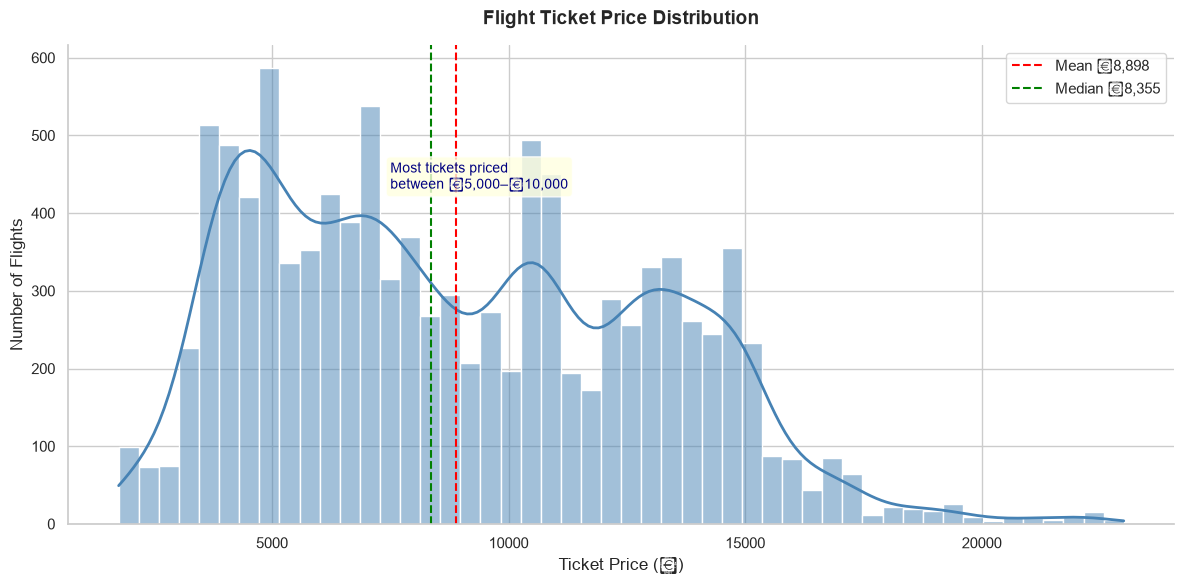

✅ Chart 1 saved


In [41]:
# ── Chart 1 : Price distribution ─────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(
    df['Price'], bins=50, kde=True,
    color='steelblue', edgecolor='white',
    line_kws={'linewidth': 2}, ax=ax
)

# Add vertical lines for mean and median
ax.axvline(df['Price'].mean(),
           color='red', linestyle='--',
           linewidth=1.5, label=f"Mean ₹{df['Price'].mean():,.0f}")
ax.axvline(df['Price'].median(),
           color='green', linestyle='--',
           linewidth=1.5, label=f"Median ₹{df['Price'].median():,.0f}")

ax.set_title('Flight Ticket Price Distribution')
ax.set_xlabel('Ticket Price (₹)')
ax.set_ylabel('Number of Flights')
ax.legend()

# Insight annotation
ax.annotate(
    'Most tickets priced\nbetween ₹5,000–₹10,000',
    xy=(7500, ax.get_ylim()[1] * 0.7),
    fontsize=10, color='navy',
    bbox=dict(boxstyle='round,pad=0.3',
              facecolor='lightyellow', alpha=0.8)
)

plt.tight_layout()
plt.savefig(os.path.join(SCREENSHOTS,
            '01_price_distribution.png'), dpi=150)
plt.show()
print("✅ Chart 1 saved")

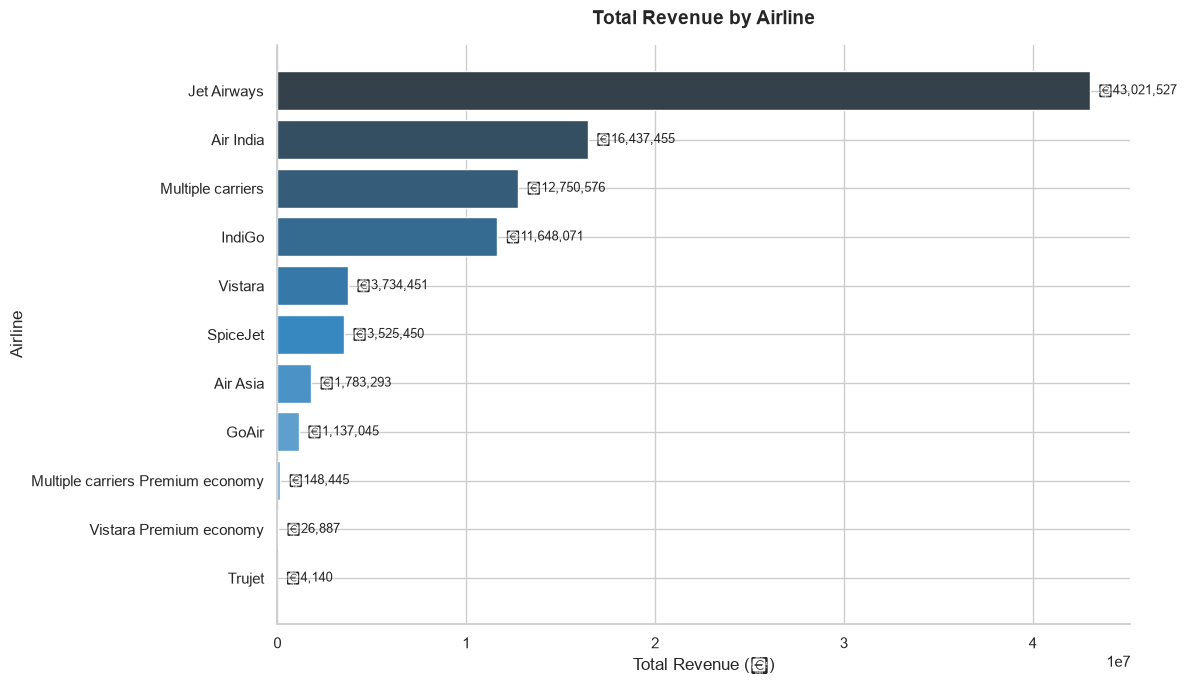

INSIGHT — REVENUE BY AIRLINE
Top airline    : Jet Airways
Total revenue  : ₹43,021,527
Avg price      : ₹11,360
Flight count   : 3,787.0
✅ Chart 2 saved


In [42]:
# ── Chart 2 : Revenue by airline ─────────────────────────
airline_rev = df.groupby('Airline').agg(
    Total_Revenue = ('Revenue', 'sum'),
    Avg_Price     = ('Price',   'mean'),
    Flight_Count  = ('Price',   'count')
).sort_values('Total_Revenue', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    airline_rev.index,
    airline_rev['Total_Revenue'],
    color=sns.color_palette('Blues_d', len(airline_rev))
)

# Add value labels
for bar, val in zip(bars,
                    airline_rev['Total_Revenue']):
    ax.text(
        bar.get_width() + airline_rev['Total_Revenue'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'₹{val:,.0f}',
        va='center', fontsize=9
    )

ax.set_title('Total Revenue by Airline')
ax.set_xlabel('Total Revenue (₹)')
ax.set_ylabel('Airline')
plt.tight_layout()
plt.savefig(os.path.join(SCREENSHOTS,
            '02_revenue_by_airline.png'), dpi=150)
plt.show()

# Print insight
print("=" * 55)
print("INSIGHT — REVENUE BY AIRLINE")
print("=" * 55)
top = airline_rev.sort_values(
    'Total_Revenue', ascending=False).iloc[0]
print(f"Top airline    : {top.name}")
print(f"Total revenue  : ₹{top['Total_Revenue']:,.0f}")
print(f"Avg price      : ₹{top['Avg_Price']:,.0f}")
print(f"Flight count   : {top['Flight_Count']:,}")
print("✅ Chart 2 saved")

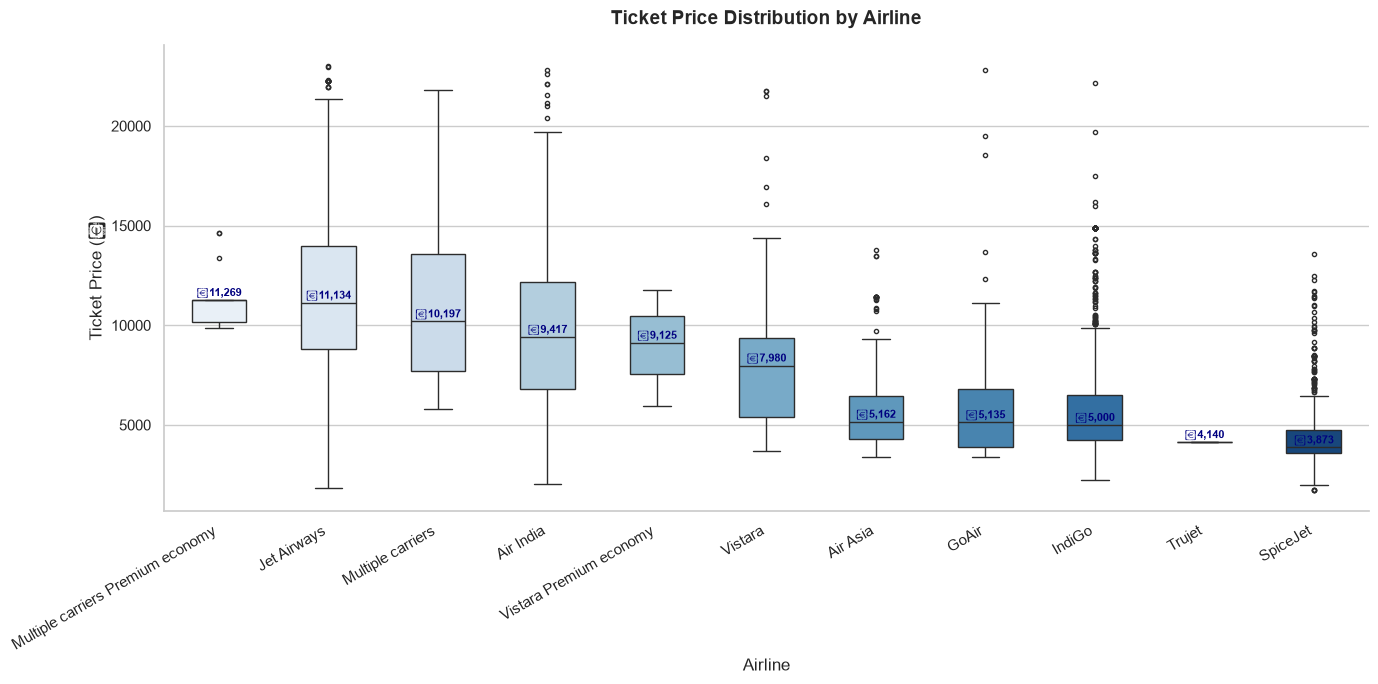

INSIGHT — PRICE BY AIRLINE
                                    median     mean   min    max
Airline                                                         
Multiple carriers Premium economy 11269.00 11418.85  9845  14629
Jet Airways                       11134.00 11360.32  1840  23001
Multiple carriers                 10197.00 10750.91  5797  21829
Air India                          9417.00  9463.13  2050  22798
Vistara Premium economy            9125.00  8962.33  5969  11793
Vistara                            7980.00  7796.35  3687  21730
Air Asia                           5162.00  5590.26  3383  13774
GoAir                              5135.00  5861.06  3398  22794
IndiGo                             5000.00  5673.68  2227  22153
Trujet                             4140.00  4140.00  4140   4140
SpiceJet                           3873.00  4315.12  1759  13552
✅ Chart 3 saved


In [43]:
# ── Chart 3 : Airline price boxplot ──────────────────────
order = df.groupby('Airline')['Price']\
          .median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(
    data=df, x='Airline', y='Price',
    order=order, palette='Blues',
    width=0.5, fliersize=3, ax=ax
)

ax.set_title('Ticket Price Distribution by Airline')
ax.set_xlabel('Airline')
ax.set_ylabel('Ticket Price (₹)')
plt.xticks(rotation=30, ha='right')

# Add median labels
for i, airline in enumerate(order):
    median = df[df['Airline'] == airline]['Price'].median()
    ax.text(i, median + 200, f'₹{median:,.0f}',
            ha='center', fontsize=8, color='navy',
            fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(SCREENSHOTS,
            '03_airline_price_boxplot.png'), dpi=150)
plt.show()

print("=" * 55)
print("INSIGHT — PRICE BY AIRLINE")
print("=" * 55)
airline_stats = df.groupby('Airline')['Price'].agg(
    ['median', 'mean', 'min', 'max'])
print(airline_stats.sort_values('median', ascending=False))
print("✅ Chart 3 saved")

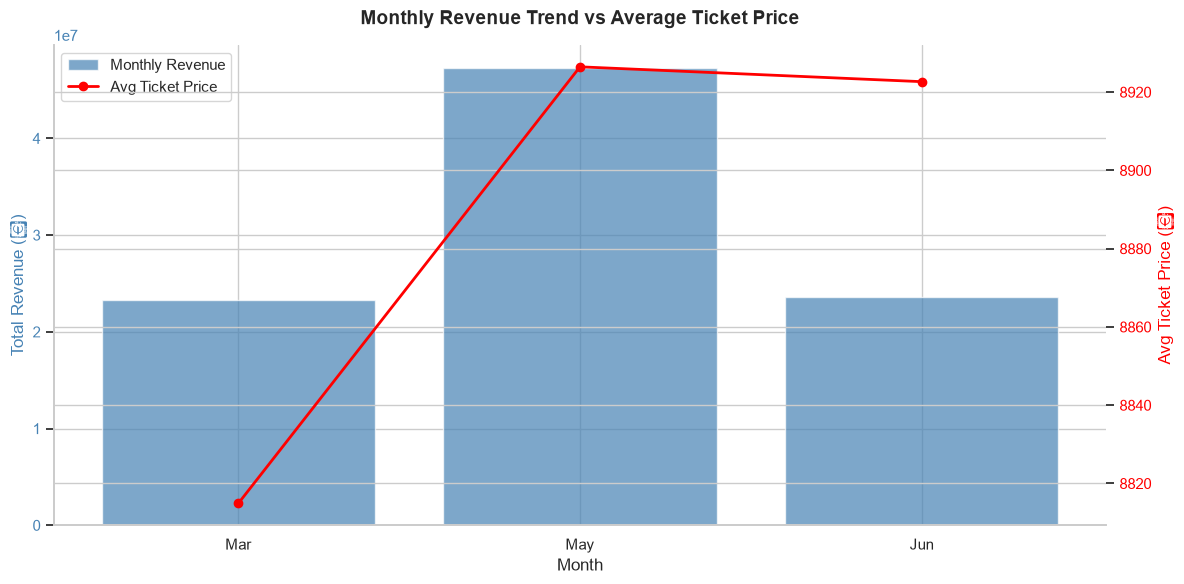

INSIGHT — MONTHLY TREND
Peak month     : May (₹47,283,453)
Lowest month   : Mar (₹23,297,748)
Peak avg price : ₹8,926
✅ Chart 4 saved


In [44]:
# ── Chart 4 : Monthly revenue trend ──────────────────────
monthly = df.groupby(['journey_month', 'month_name']).agg(
    Revenue      = ('Revenue', 'sum'),
    Avg_Price    = ('Price',   'mean'),
    Flight_Count = ('Price',   'count')
).reset_index().sort_values('journey_month')

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Bars — monthly revenue
bars = ax1.bar(
    monthly['month_name'],
    monthly['Revenue'],
    color='steelblue', alpha=0.7,
    label='Monthly Revenue'
)

# Line — avg price
ax2.plot(
    monthly['month_name'],
    monthly['Avg_Price'],
    color='red', marker='o',
    linewidth=2, markersize=6,
    label='Avg Ticket Price'
)

ax1.set_title('Monthly Revenue Trend vs Average Ticket Price')
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Revenue (₹)', color='steelblue')
ax2.set_ylabel('Avg Ticket Price (₹)', color='red')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='red')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(SCREENSHOTS,
            '04_monthly_revenue_trend.png'), dpi=150)
plt.show()

print("=" * 55)
print("INSIGHT — MONTHLY TREND")
print("=" * 55)
peak = monthly.loc[monthly['Revenue'].idxmax()]
low  = monthly.loc[monthly['Revenue'].idxmin()]
print(f"Peak month     : {peak['month_name']} "
      f"(₹{peak['Revenue']:,.0f})")
print(f"Lowest month   : {low['month_name']} "
      f"(₹{low['Revenue']:,.0f})")
print(f"Peak avg price : ₹{peak['Avg_Price']:,.0f}")
print("✅ Chart 4 saved")

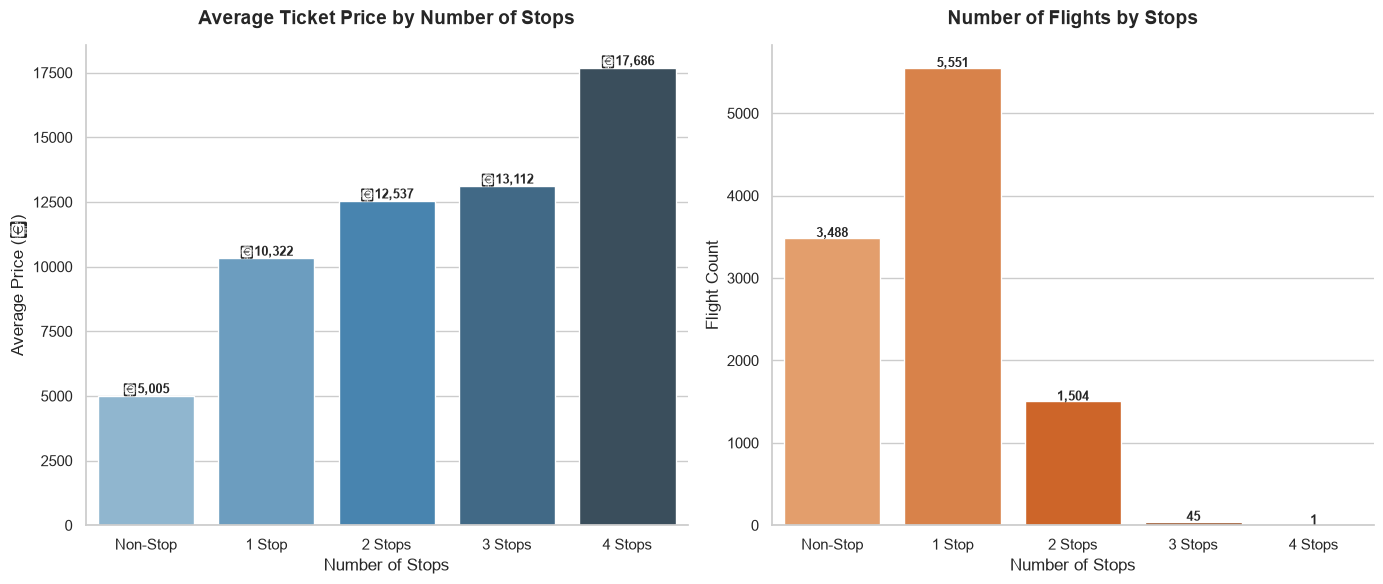

INSIGHT — STOPS VS PRICE
stop_label  Avg_Price  Flight_Count  Total_Rev
  Non-Stop    5005.27          3488   17458366
    1 Stop   10321.73          5551   57295918
   2 Stops   12536.79          1504   18855330
   3 Stops   13112.00            45     590040
   4 Stops   17686.00             1      17686
✅ Chart 5 saved


In [45]:
# ── Chart 5 : Stops vs average price ─────────────────────
stops_analysis = df.groupby('stops_clean').agg(
    Avg_Price    = ('Price',   'mean'),
    Total_Rev    = ('Revenue', 'sum'),
    Flight_Count = ('Price',   'count')
).reset_index()

stops_analysis['stop_label'] = stops_analysis[
    'stops_clean'].map({
        0: 'Non-Stop',
        1: '1 Stop',
        2: '2 Stops',
        3: '3 Stops',
        4: '4 Stops'
    })

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — avg price by stops
sns.barplot(
    data=stops_analysis,
    x='stop_label', y='Avg_Price',
    palette='Blues_d', ax=axes[0]
)
axes[0].set_title('Average Ticket Price by Number of Stops')
axes[0].set_xlabel('Number of Stops')
axes[0].set_ylabel('Average Price (₹)')
for i, row in stops_analysis.iterrows():
    axes[0].text(
        i, row['Avg_Price'] + 100,
        f"₹{row['Avg_Price']:,.0f}",
        ha='center', fontsize=9, fontweight='bold'
    )

# Right — flight count by stops
sns.barplot(
    data=stops_analysis,
    x='stop_label', y='Flight_Count',
    palette='Oranges_d', ax=axes[1]
)
axes[1].set_title('Number of Flights by Stops')
axes[1].set_xlabel('Number of Stops')
axes[1].set_ylabel('Flight Count')
for i, row in stops_analysis.iterrows():
    axes[1].text(
        i, row['Flight_Count'] + 10,
        f"{row['Flight_Count']:,}",
        ha='center', fontsize=9, fontweight='bold'
    )

plt.tight_layout()
plt.savefig(os.path.join(SCREENSHOTS,
            '05_stops_vs_price.png'), dpi=150)
plt.show()

print("=" * 55)
print("INSIGHT — STOPS VS PRICE")
print("=" * 55)
print(stops_analysis[['stop_label', 'Avg_Price',
                       'Flight_Count', 'Total_Rev']]
      .to_string(index=False))
print("✅ Chart 5 saved")

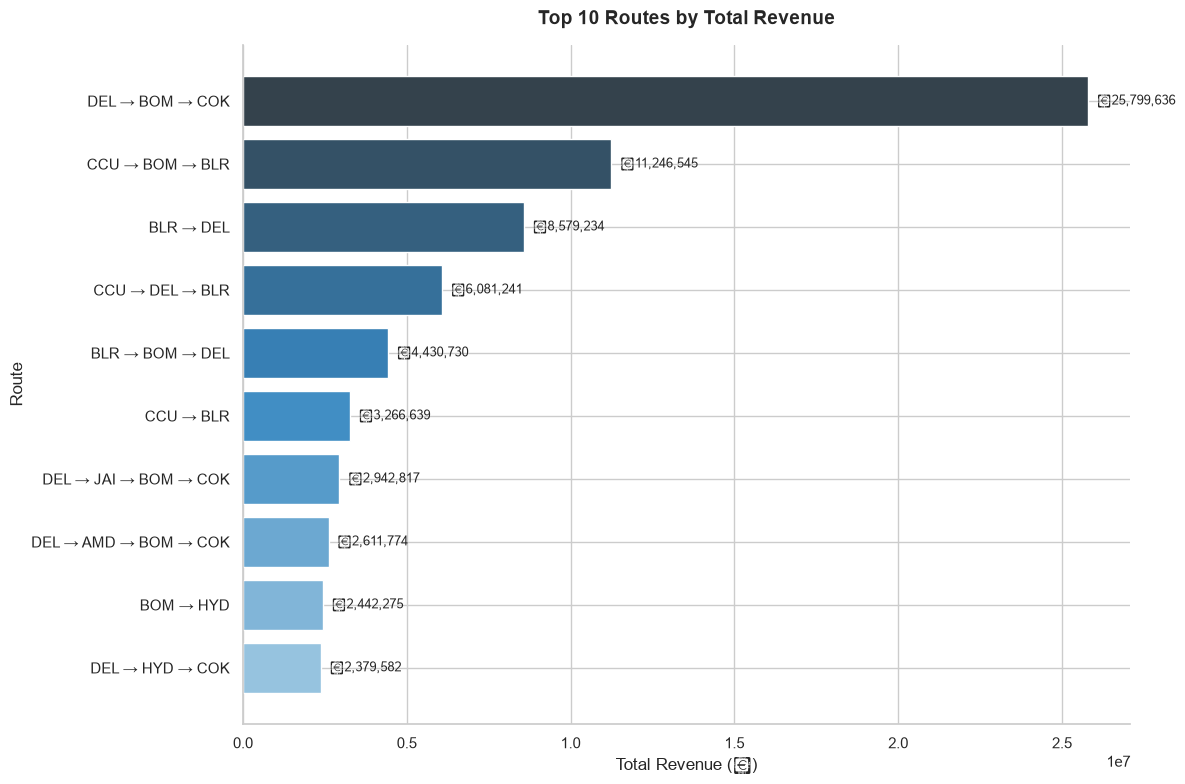

INSIGHT — TOP 10 ROUTES
                       Total_Revenue  Avg_Price  Flight_Count
Route                                                        
DEL → BOM → COK             25799636   10895.12          2368
CCU → BOM → BLR             11246545   11487.79           979
BLR → DEL                    8579234    5534.99          1550
CCU → DEL → BLR              6081241   10763.26           565
BLR → BOM → DEL              4430730   12993.34           341
CCU → BLR                    3266639    4518.17           723
DEL → JAI → BOM → COK        2942817   12261.74           240
DEL → AMD → BOM → COK        2611774   12740.36           205
BOM → HYD                    2442275    3932.81           621
DEL → HYD → COK              2379582    7299.33           326
✅ Chart 6 saved


In [46]:
# ── Chart 6 : Top 10 routes ───────────────────────────────
top_routes = df.groupby('Route').agg(
    Total_Revenue = ('Revenue', 'sum'),
    Avg_Price     = ('Price',   'mean'),
    Flight_Count  = ('Price',   'count')
).sort_values('Total_Revenue', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    top_routes.index[::-1],
    top_routes['Total_Revenue'][::-1],
    color=sns.color_palette('Blues_d', 10)
)

for bar, val in zip(bars,
                    top_routes['Total_Revenue'][::-1]):
    ax.text(
        bar.get_width() +
        top_routes['Total_Revenue'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'₹{val:,.0f}',
        va='center', fontsize=9
    )

ax.set_title('Top 10 Routes by Total Revenue')
ax.set_xlabel('Total Revenue (₹)')
ax.set_ylabel('Route')
plt.tight_layout()
plt.savefig(os.path.join(SCREENSHOTS,
            '06_top_10_routes.png'), dpi=150)
plt.show()

print("=" * 55)
print("INSIGHT — TOP 10 ROUTES")
print("=" * 55)
print(top_routes[['Total_Revenue',
                  'Avg_Price',
                  'Flight_Count']].to_string())
print("✅ Chart 6 saved")

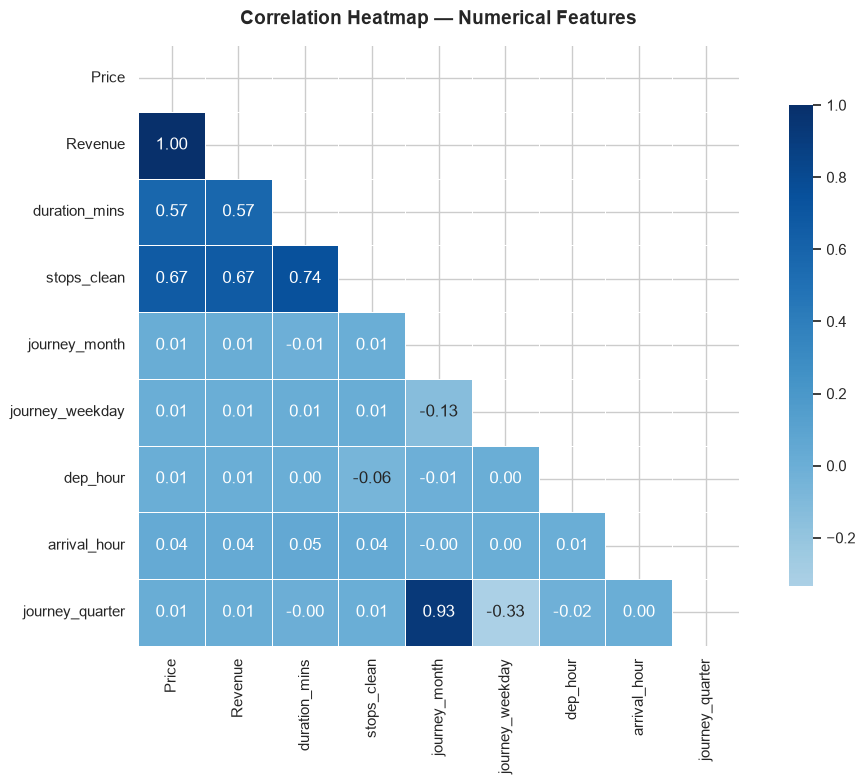

INSIGHT — CORRELATIONS WITH PRICE
  Revenue            : +1.00 (strong positive)
  stops_clean        : +0.67 (strong positive)
  duration_mins      : +0.57 (strong positive)
  arrival_hour       : +0.04 (weak positive)
  journey_quarter    : +0.01 (weak positive)
  journey_month      : +0.01 (weak positive)
  journey_weekday    : +0.01 (weak positive)
  dep_hour           : +0.01 (weak positive)
✅ Chart 8 saved


In [48]:
# ── Chart 8 : Correlation heatmap ────────────────────────
num_cols = ['Price', 'Revenue', 'duration_mins',
            'stops_clean', 'journey_month',
            'journey_weekday', 'dep_hour',
            'arrival_hour', 'journey_quarter']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True,
    fmt='.2f', cmap='Blues',
    center=0, square=True,
    linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.8}
)

ax.set_title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.savefig(os.path.join(SCREENSHOTS,
            '08_correlation_heatmap.png'), dpi=150)
plt.show()

print("=" * 55)
print("INSIGHT — CORRELATIONS WITH PRICE")
print("=" * 55)
price_corr = corr['Price'].drop('Price')\
                           .sort_values(ascending=False)
for col, val in price_corr.items():
    direction = 'positive' if val > 0 else 'negative'
    strength  = ('strong' if abs(val) > 0.5
                 else 'moderate' if abs(val) > 0.3
                 else 'weak')
    print(f"  {col:<18} : {val:+.2f} "
          f"({strength} {direction})")
print("✅ Chart 8 saved")

In [49]:
# ── Actionable insights summary ───────────────────────────
print("=" * 55)
print("ACTIONABLE INSIGHTS — AIRLINE REVENUE DASHBOARD")
print("=" * 55)

top_airline = df.groupby('Airline')['Revenue']\
                .sum().idxmax()
top_route   = df.groupby('Route')['Revenue']\
                .sum().idxmax()
peak_month  = df.groupby('month_name')['Revenue']\
                .sum().idxmax()
best_stops  = df.groupby('stops_clean')['Price']\
                .mean().idxmax()
top_source  = df.groupby('Source')['Revenue']\
                .sum().idxmax()

print(f"""
1. TOP AIRLINE
   {top_airline} generates the highest total revenue.
   Action: Prioritise this airline in partnership deals.

2. TOP ROUTE
   {top_route} is the most profitable route.
   Action: Increase flight frequency on this route.

3. PEAK MONTH
   {peak_month} sees the highest revenue — likely a holiday period.
   Action: Dynamic pricing should be applied in this month.

4. STOPS INSIGHT
   {best_stops}-stop flights command the highest average price.
   Action: Premium non-stop routes should be protected
   from low-cost competition.

5. SOURCE CITY
   {top_source} is the highest revenue departure city.
   Action: Marketing spend should be concentrated here.

6. PRICE BAND
   Mid-Range tickets (₹5k-₹10k) dominate flight count
   but Premium tickets drive revenue per seat.
   Action: Upsell campaigns should target Mid-Range
   customers to move them to Premium.

7. DURATION
   Longer flights correlate with higher prices.
   Action: Long-haul routes have strongest pricing power
   — protect margins on these routes first.
""")
print("=" * 55)
print("✅ Full EDA complete — all 8 charts saved to")
print(f"   {SCREENSHOTS}")

ACTIONABLE INSIGHTS — AIRLINE REVENUE DASHBOARD

1. TOP AIRLINE
   Jet Airways generates the highest total revenue.
   Action: Prioritise this airline in partnership deals.

2. TOP ROUTE
   DEL → BOM → COK is the most profitable route.
   Action: Increase flight frequency on this route.

3. PEAK MONTH
   May sees the highest revenue — likely a holiday period.
   Action: Dynamic pricing should be applied in this month.

4. STOPS INSIGHT
   4-stop flights command the highest average price.
   Action: Premium non-stop routes should be protected
   from low-cost competition.

5. SOURCE CITY
   Delhi is the highest revenue departure city.
   Action: Marketing spend should be concentrated here.

6. PRICE BAND
   Mid-Range tickets (₹5k-₹10k) dominate flight count
   but Premium tickets drive revenue per seat.
   Action: Upsell campaigns should target Mid-Range
   customers to move them to Premium.

7. DURATION
   Longer flights correlate with higher prices.
   Action: Long-haul routes have st